# EDA и бинарная классификация на датасете «Spaceship Titanic»
**Дисциплина:** Машинное обучение и ИИ

**Модуль 1:** Введение в Data Science и EDA

**Датасет:** Spaceship Titanic

**Выполнила:** Гурьевская Валерия Евгеньевна

**Группа:** ПКТб-23-1

**Преподаватель:** Спирин Игорь Сергеевич

**Ссылка на репозиторий:** https://github.com/GuryevskayaValeriya/ml-course-guryevskaya

**Путь к модулю:** `module-1-titanic/notebook.ipynb`

**Дата сдачи:** 2026-09-22


## Введение

**Задача:** решается задача бинарной классификации; предсказать, был ли космический пассажир перемещен в другое пространственно-временное измерение в результате аномалии космического корабля «Spaceship Titanic» (целевая переменная `Transported`: True / 1 - перемещен, False / 0 - не перемещен).

**Обоснование выбора датасета Spaceship Titanic:** датасет «Spaceship Titanic» представляет собой усложненный аналог классического «Титаника», содержащий более разнообразный набор признаков, а также значительную долю пропущенных значений. Работа с ним требует проведения комплексного разведочного анализа данных (EDA) и продвинутого Feature Engineering.

**ML-проект** - это комплексный жизненный цикл создания системы принятия решений на основе данных: от постановки задачи, сбора и разведочного анализа (EDA) до предобработки, конструирования признаков (feature engineering), выбора и обучения моделей, их строгой валидации, интерпретации и подготовки к развертыванию.

**Почему классификация, а не регрессия:** в задаче классификации целевая переменная является дискретной (в данном случае категориальной / бинарной: перемещен или нет). В задаче регрессии целевая переменная непрерывна (например, прогнозирование температуры или цены).

**Метрики качества:** для оценки качества используются метрики **Accuracy**, **Precision**, **Recall**, **F1-score** и **ROC-AUC**. В условиях сбалансированных классов ключевыми ориентирами служат **ROC-AUC** (оценивает ранжирующую способность модели и качество выдаваемых вероятностей независимо от порога отсечения) и **F1-score** (гармоническое среднее между точностью и полнотой).

**Цели работы:**
1. Провести детальный EDA датасета Spaceship Titanic, выявить закономерности и реализовать пайплайн обработки пропусков и генерации признаков.
2. Обучить базовые модели (Logistic Regression, Decision Tree) и дополнительную ансамблевую модель (Random Forest для получения бонусных баллов), достигнув ROC-AUC $\ge 0.80$.
3. Реализовать функцию предсказания `predict_passenger()` и организовать версионирование и сохранение артефактов в репозитории.


## Теоретическая часть

1. **Разведочный анализ данных (EDA - Exploratory Data Analysis):**  
   Это первое знакомство с данными, мы смотрим с чем предстоит работать: строим графики, ищем выбросы, странности, закономерности. Не простот посчитать среднее или дисперсию, а понять природу признаков, оценить баланс целевой переменной и выдвинуть гипотезы, которые помогут модели делать правильные предсказания.

2. **Обработка пропущенных значений (NaN):**  
   Пропуски возникают из-за технических сбоев, ошибок ввода или специфики объектов. Основные стратегии включают удаление строк/столбцов (применяется при критически большой доле пропусков или низкой информативности) и импутацию - заполнение медианой/модой по группам или медианой числовых признаков, что сохраняет объем выборки.

3. **Кодирование категориальных признаков:**
| Метод | Определение | Преимущество |
|---|---|---|
| **One-Hot Encoding** | Формирует бинарные индикаторы для каждого уровня категории | Исключает ложное предположение об упорядоченности категорий, являясь стандартом для линейных моделей |
| **Label Encoding** | Сопоставляет каждой категории числовой индекс | Подходит для порядковых признаков или бинарных меток |


4. **Масштабирование признаков:**  
| Метод | Определение | Преимущество |
|---|---|---|
| **StandardScaler** | Преобразует признаки к виду со средним $\mu = 0$ и дисперсией $\sigma^2 = 1$ | Важно для линейных моделей (Logistic Regression) и методов регуляризации |
| **MinMaxScaler** | Сжимает значения признаков в диапазон $[0, 1]$ | Подходит для признаков с ограниченным физическим диапазоном |

5. **Feature Engineering (Конструирование признаков):**  
   Процесс создания новых признаков из сырых данных на основе предметной логики (например, суммирование затрат пассажира, разбивка каюты на палубу и борт). Обычно сырых данных алгоритму мало и мы создаем новые столбцы, чтобы повысить выразительную способность алгоритмов машинного обучения.

6. **Метрики бинарной классификации:**  
   - **Accuracy**: доля верных классификаций.
   - **Precision**: доля истинно положительных среди всех объектов, которым присвоен положительный класс.
   - **Recall**: способность модели обнаруживать объекты положительного класса.
   - **F1-score**: гармоническое среднее Precision и Recall.
   - **ROC-AUC**: площадь под ROC-кривой (зависимость True Positive Rate от False Positive Rate).

**Математические формулы метрик:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

$$TPR = \frac{TP}{TP + FN} \quad FPR = \frac{FP}{FP + TN}$$





## Описание данных

**Источник:** Kaggle Competition — Spaceship Titanic (https://www.kaggle.com/c/spaceship-titanic)  

**Структура датасета:**
- Всего примеров в обучающей выборке (`train.csv`): 8693
- Всего примеров в тестовой выборке (`test.csv`): 4277
- Признаков: 13 независимых признаков + целевая переменная `Transported`
- Числовые признаки (6): `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`
- Категориальные / текстовые признаки (7) : `PassengerId`, `HomePlanet`, `CryoSleep`, `Cabin`, `Destination`, `VIP`, `Name`
- Целевой признак: `Transported` (`True` / `False`)

### Описание колонок Spaceship Titanic:

| Столбец | Тип | Описание | Доля пропусков |
|---|---|---|---|
| `PassengerId` | object | Уникальный идентификатор пассажира формата `gggg_pp` | 0.0% |
| `HomePlanet` | object | Планета отправления (Earth, Europa, Mars) | ~2.3% |
| `CryoSleep` | object | Находился ли пассажир в криосне (True/False) | ~2.5% |
| `Cabin` | object | Каюта формата `Deck/Num/Side` (борт P - Port или S - Starboard) | ~2.3% |
| `Destination` | object | Планета назначения | ~2.1% |
| `Age` | float64 | Возраст пассажира | ~2.1% |
| `VIP` | object | Оплачен ли специальный VIP-сервис | ~2.4% |
| `RoomService` | float64 | Сумма расходов пассажира на обслуживание в каюте | ~2.1% |
| `FoodCourt` | float64 | Расходы на фудкорт | ~2.1% |
| `ShoppingMall` | float64 | Расходы на торговый центр | ~2.4% |
| `Spa` | float64 | Расходы на спа-салон | ~2.1% |
| `VRDeck` | float64 | Расходы на шлем виртуальной реальности | ~2.2% |
| `Name` | object | Имя и фамилия пассажира | ~2.3% |
| `Transported` | bool | Целевая метка: был ли пассажир перемещен в другое измерение | 0.0% |

- Размер train_df: (8693, 14)
- Размер test_df:  (4277, 13)


Распределение целевой переменной Transported:
- Класс True: 4378 объектов (50.36%)
- Класс False: 4315 объектов (49.64%)

**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

In [3]:
# импорт основных библиотек анализа данных и визуализации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore') # отключает вывод предупреждений

# настройка единого стиля визуализации
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('crest')

# пути к данным
train_path = 'data/train.csv'
test_path = 'data/test.csv'

# загрузка датасета
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Размер train_df: {train_df.shape}")
print(f"Размер test_df:  {test_df.shape}")
print("-" * 50)
print(train_df.info())
# доля пропусков по всем колонкам в процентах
print((train_df.isnull().mean() * 100).round(2))

Размер train_df: (8693, 14)
Размер test_df:  (4277, 13)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
PassengerId     0.00
HomePlane

In [4]:
# вывод доли классов целевой переменной Transported
target_counts = train_df['Transported'].value_counts()
target_pct = train_df['Transported'].value_counts(normalize=True) * 100

print("Распределение целевой переменной Transported:")
for val, count in target_counts.items():
    print(f"Класс {val}: {count} объектов ({target_pct[val]:.2f}%)")


Распределение целевой переменной Transported:
Класс True: 4378 объектов (50.36%)
Класс False: 4315 объектов (49.64%)


## Подготовка данных и EDA



In [5]:
# первичный осмотр
print(train_df.head())
print(train_df.describe())

# проверка пропусков
missing_val = train_df.isnull().sum()
missing_pct = (missing_val / len(train_df)) * 100 # в процентах
missing_summary = pd.DataFrame({'Missing Values': missing_val, 'Percentage (%)': missing_pct}) # таблица
print(missing_summary[missing_summary['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False))


  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
  

Сводная таблица пропущенных значений:


,Тип данных,Количество пропусков,Доля пропусков (%)
CryoSleep,object,217,2.50
ShoppingMall,float64,208,2.39
VIP,object,203,2.34
HomePlanet,object,201,2.31
Name,object,200,2.30
Cabin,object,199,2.29
VRDeck,float64,188,2.16
FoodCourt,float64,183,2.11
Spa,float64,183,2.11
Destination,object,182,2.09


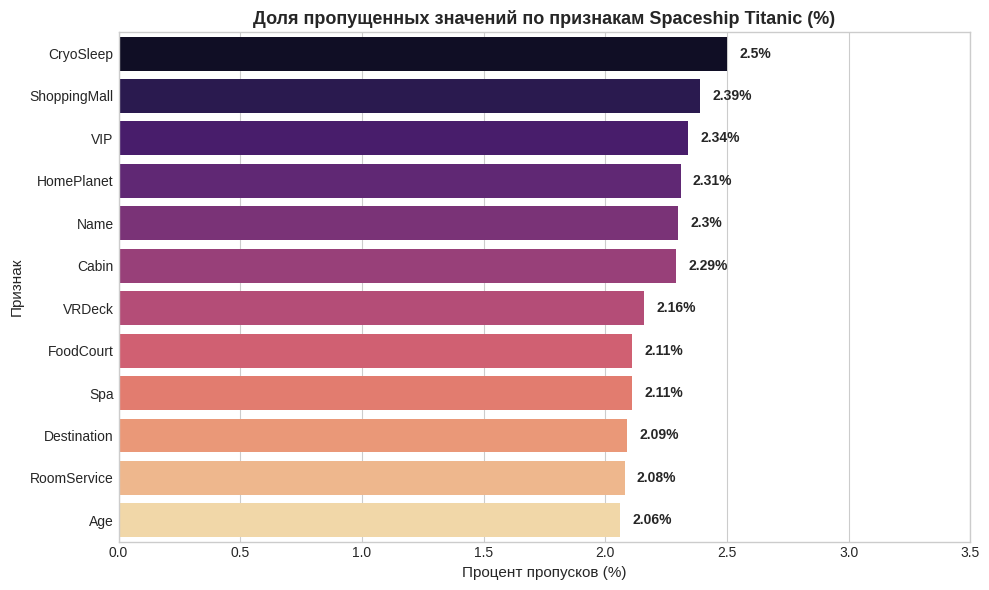

In [6]:
# анализ пропусков

# абсолютное количество пропусков по каждому столбцу
missing_counts = train_df.isnull().sum()

# процентная доля пропусков относительно общего объема выборки
missing_percent = (train_df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    'Тип данных': train_df.dtypes,
    'Количество пропусков': missing_counts,
    'Доля пропусков (%)': missing_percent
})

# фильтруем признаки, где есть хотя бы один пропуск, и сортируем по убыванию
missing_only = missing_table[missing_table['Количество пропусков'] > 0].sort_values(
    by='Доля пропусков (%)',
    ascending=False
)

print("Сводная таблица пропущенных значений:")
display(missing_only)

# визуализация доли пропусков в виде горизонтального барплота
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_only['Доля пропусков (%)'],
    y=missing_only.index,
    palette='magma'
)
plt.title('Доля пропущенных значений по признакам Spaceship Titanic (%)', fontsize=13, fontweight='bold')
plt.xlabel('Процент пропусков (%)', fontsize=11)
plt.ylabel('Признак', fontsize=11)
plt.xlim(0, 3.5)  # задаем масштаб по оси X для наглядности

# добавляем текстовые подписи с процентами к каждому столбцу
for index, value in enumerate(missing_only['Доля пропусков (%)']):
    plt.text(value + 0.05, index, f"{value}%", va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

In [7]:
# статистический анализ числовых и категориальных признаков

# непрерывные числовые признаки (возраст и траты по зонам корабля)
numeric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# расчет коэффициента асимметрии (Skewness)
# Skew > 0: правосторонняя асимметрия (длинный хвост вправо)
skew_vals = train_df[numeric_features].skew()

# расчет коэффициента эксцесса (Kurtosis)
# Kurtosis > 0: островершинное распределение с тяжелыми хвостами (выбросами)
kurt_vals = train_df[numeric_features].kurtosis()

# сравнительная таблица формы распределений
shape_stats_df = pd.DataFrame({
    'Skewness (Асимметрия)': skew_vals.round(3),
    'Kurtosis (Эксцесс)': kurt_vals.round(3),
    'Медиана': train_df[numeric_features].median(),
    'Среднее': train_df[numeric_features].mean().round(2)
})

print("Форма распределений числовых признаков:")
display(shape_stats_df)

# частотный анализ (value_counts) для ключевых категориальных признаков
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported']

# таблица
print("\nЧастотный анализ ключевых категориальных признаков (value_counts):")
for col in cat_features:
    print(f"\nПризнак: {col}")
    counts = train_df[col].value_counts(dropna=False)
    percents = train_df[col].value_counts(dropna=False, normalize=True) * 100
    cat_summary = pd.DataFrame({'Количество': counts, 'Доля (%)': percents.round(2)})
    display(cat_summary)

Форма распределений числовых признаков:


,Skewness (Асимметрия),Kurtosis (Эксцесс),Медиана,Среднее
Age,0.419,0.102,27.0,28.83
RoomService,6.333,65.274,0.0,224.69
FoodCourt,7.102,73.307,0.0,458.08
ShoppingMall,12.628,328.871,0.0,173.73
Spa,7.636,81.202,0.0,311.14
VRDeck,7.820,86.011,0.0,304.85



Частотный анализ ключевых категориальных признаков (value_counts):

Признак: HomePlanet


,Количество,Доля (%)
HomePlanet,,
Earth,4602,52.94
Europa,2131,24.51
Mars,1759,20.23
NaN,201,2.31



Признак: CryoSleep


...

,Количество,Доля (%)
Destination,,
TRAPPIST-1e,5915,68.04
55 Cancri e,1800,20.71
PSO J318.5-22,796,9.16
NaN,182,2.09



Признак: VIP


,Количество,Доля (%)
VIP,,
False,8291,95.38
NaN,203,2.34
True,199,2.29



Признак: Transported


,Количество,Доля (%)
Transported,,
True,4378,50.36
False,4315,49.64


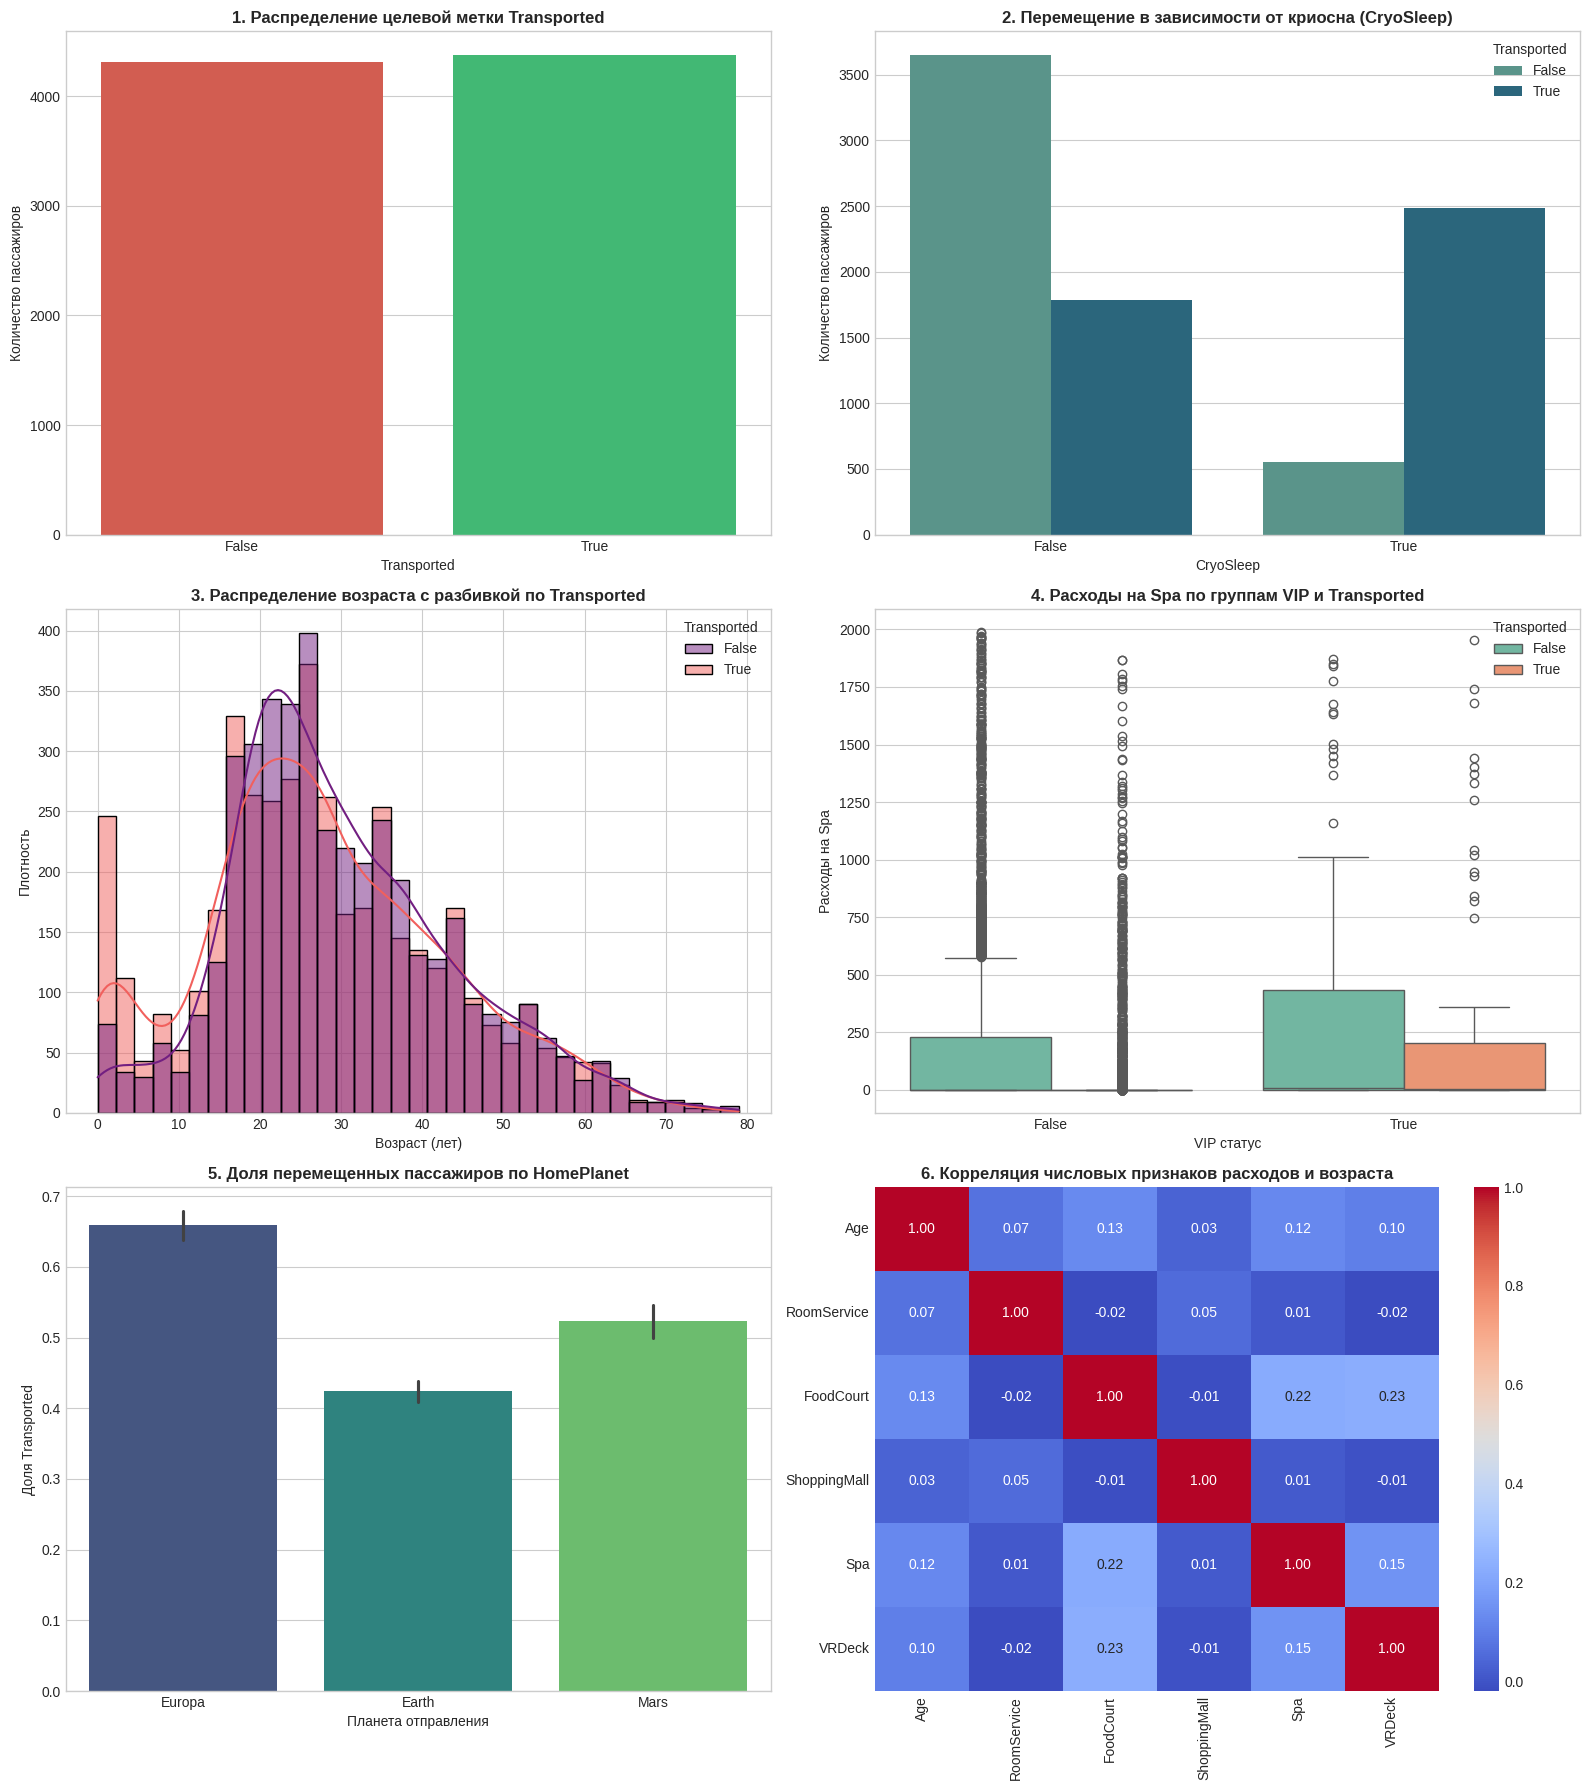

In [8]:
# Построение аналитических визуализаций (сетка графиков)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# График 1: Распределение целевой переменной Transported
sns.countplot(data=train_df, x='Transported', ax=axes[0, 0], palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('1. Распределение целевой метки Transported', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transported')
axes[0, 0].set_ylabel('Количество пассажиров')

# График 2: Связь криосна (CryoSleep) и вероятности перемещения
sns.countplot(data=train_df, x='CryoSleep', hue='Transported', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('2. Перемещение в зависимости от криосна (CryoSleep)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('CryoSleep')
axes[0, 1].set_ylabel('Количество пассажиров')

# График 3: Распределение возраста Age в разрезе Transported
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, bins=35, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('3. Распределение возраста с разбивкой по Transported', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Возраст (лет)')
axes[1, 0].set_ylabel('Плотность')

# График 4: Boxplot расходов на Spa в зависимости от VIP и Transported
spend_sub = train_df[train_df['Spa'] < 2000] # Ограничение экстремальных выбросов для наглядности
sns.boxplot(data=spend_sub, x='VIP', y='Spa', hue='Transported', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('4. Расходы на Spa по группам VIP и Transported', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('VIP статус')
axes[1, 1].set_ylabel('Расходы на Spa')

# График 5: Доля перемещенных в зависимости от родной планеты (HomePlanet)
sns.barplot(data=train_df, x='HomePlanet', y='Transported', ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('5. Доля перемещенных пассажиров по HomePlanet', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Планета отправления')
axes[2, 0].set_ylabel('Доля Transported')

# График 6: Корреляционная матрица числовых признаков
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
corr_matrix = train_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, ax=axes[2, 1])
axes[2, 1].set_title('6. Корреляция числовых признаков расходов и возраста', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Выводы по разведочному анализу (EDA):
1. **Баланс классов:** Классы `Transported` распределены практически поровну (примерно 50.4% `True` и 49.6% `False`), что исключает проблему катастрофического дисбаланса.
2. **Фактор криосна (`CryoSleep`):** Является мощным предиктором: пассажиры в криосне перемещались со значительно более высокой вероятностью (~80%), чем пассажиры без криосна.
3. **Возраст (`Age`):** Дети в возрасте до 12 лет имели повышенную вероятность перемещения, аналогично паттернам приоритетной эвакуации.
4. **Траты на борту (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`):** Пассажиры, находившиеся в криосне, тратили 0 кредитов. Пассажиры с высокими тратами на бортовые услуги реже подвергались переносу аномалией.
5. **Родная планета (`HomePlanet`):** Пассажиры с планеты `Europa` имеют наивысшую долю перемещения (около 66%), тогда как пассажиры с Земли (`Earth`) - наименьшую (около 42%).


In [9]:
# Feature Engineering и обработка пропусков

def preprocess_spaceship_data(df, is_train=True):
    # создаем копию
    df_clean = df.copy()

    # извлечение информации из PassengerId (размер группы)
    # идентификатор имеет формат gggg_pp, где gggg - номер группы
    df_clean['GroupId'] = df_clean['PassengerId'].apply(lambda x: x.split('_')[0])
    group_sizes = df_clean['GroupId'].value_counts()
    df_clean['Group_Size'] = df_clean['GroupId'].map(group_sizes)
    df_clean['Is_Alone'] = (df_clean['Group_Size'] == 1).astype(int)

    # обработка Cabin (Deck / Num / Side)
    # заполняем пропуски каюты заглушкой
    df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown/0/Unknown')
    cabin_split = df_clean['Cabin'].str.split('/', expand=True)
    df_clean['Deck'] = cabin_split[0]
    df_clean['Side'] = cabin_split[2]
    # заменяем редкие/неизвестные палубы на наиболее частые или категорию Other
    top_decks = ['B', 'C', 'E', 'F', 'G']
    df_clean['Deck'] = df_clean['Deck'].apply(lambda d: d if d in top_decks else 'Other')
    df_clean['Side'] = df_clean['Side'].apply(lambda s: s if s in ['P', 'S'] else 'Unknown')

    # обработка числовых расходов:
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        # пропуски заполняем 0 (в большинстве случаев пассажиры не тратили средства)
        df_clean[col] = df_clean[col].fillna(0.0)

    df_clean['Total_Spend'] = df_clean[spend_cols].sum(axis=1)
    df_clean['Zero_Spend'] = (df_clean['Total_Spend'] == 0).astype(int)

    # обработка возраста Age (заполнение медианой)
    age_median = df_clean['Age'].median()
    df_clean['Age'] = df_clean['Age'].fillna(age_median)

    # обработка бинарных признаков CryoSleep и VIP
    # пассажиры с Total_Spend == 0 часто находятся в CryoSleep
    cryo_fill = (df_clean['Total_Spend'] == 0)
    df_clean['CryoSleep'] = df_clean['CryoSleep'].fillna(cryo_fill).astype(int)
    df_clean['VIP'] = df_clean['VIP'].fillna(False).astype(int)

    # заполнение категориальных признаков HomePlanet и Destination модой
    df_clean['HomePlanet'] = df_clean['HomePlanet'].fillna(df_clean['HomePlanet'].mode()[0])
    df_clean['Destination'] = df_clean['Destination'].fillna(df_clean['Destination'].mode()[0])

    # One-Hot Encoding категориальных колонок
    cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
    df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

    if is_train and 'Transported' in df_clean.columns:
        df_clean['Transported'] = df_clean['Transported'].astype(int)

    return df_clean

# применяем пайплайн предобработки
processed_train = preprocess_spaceship_data(train_df, is_train=True)
print("Предобработка завершена. Новая форма таблицы:", processed_train.shape)
print("Список сформированных колонок:", list(processed_train.columns))


Предобработка завершена. Новая форма таблицы: (8693, 28)
Список сформированных колонок: ['PassengerId', 'CryoSleep', 'Cabin', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported', 'GroupId', 'Group_Size', 'Is_Alone', 'Total_Spend', 'Zero_Spend', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Deck_C', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Other', 'Side_S', 'Side_Unknown']


# Обоснование заполнения пропусков
- Расходы (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) $\rightarrow$ 0.0

Медиана трат равна нулю (большинство пассажиров ничего не покупали), а среднее сильно завышено из-за редких крупных чеков. Пропуск означает, что пассажир не пользовался услугой.
- Возраст (Age) $\rightarrow$ Медиана

Медиана устойчива к выбросам и не сдвигает центр распределения в отличие от среднего арифметического.
- Криосон (CryoSleep) $\rightarrow$ True, если Total_Spend == 0, иначе False

В криосне физически нельзя тратить деньги. Если есть траты — пассажир точно бодрствовал, если трат ноль — с высокой вероятностью спал.
- VIP-статус (VIP) $\rightarrow$ False (0)

VIP-пассажиров всего 2.3%, поэтому пропуски заполняются самым частым значением (модой).
- Планеты (HomePlanet, Destination) $\rightarrow$ Мода

Категориальные признаки с малой долей пропусков (~2%), которые логично заполнить доминирующими маршрутами (Earth и TRAPPIST-1e).
- Каюта (Cabin) $\rightarrow$ Заглушка Unknown/0/Unknown

Каюту нельзя заполнить модой из-за уникальности номеров. Заглушка сохраняет строки и позволяет выделить палубу и борт без потери данных.

## Построение и обучение моделей



In [10]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# выделяем признаки для обучения
excluded_cols = ['PassengerId', 'Cabin', 'Name', 'GroupId', 'Transported']
feature_cols = [c for c in processed_train.columns if c not in excluded_cols]

X = processed_train[feature_cols].astype(float)
y = processed_train['Transported']

# разделение выборки со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:   {X_test.shape}")

# масштабирование признаков (для Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. обучение Logistic Regression
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
start_lr = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_lr
print(f"⏱️ Время обучения Logistic Regression: {lr_time:.4f} сек")

# 2. обучение Decision Tree
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_split=10, min_samples_leaf=4, random_state=42)
start_dt = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start_dt
print(f"⏱️ Время обучения Decision Tree:      {dt_time:.4f} сек")

# 3. обучение Random Forest
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=6, random_state=42, n_jobs=-1)
start_rf = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_rf
print(f"⏱️ Время обучения Random Forest (Бонус): {rf_time:.4f} сек")


Размер обучающей выборки: (6954, 23)
Размер тестовой выборки:   (1739, 23)
⏱️ Время обучения Logistic Regression: 0.0263 сек
⏱️ Время обучения Decision Tree:      0.0244 сек
⏱️ Время обучения Random Forest (Бонус): 0.8355 сек


### Модели:

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0, max_iter=1000 | да | 0.0263 сек |
| Decision Tree | max_depth=6, min_samples_split=10, min_samples_leaf=4 | нет | 0.0244 сек |
| Random Forest | n_estimators=150, max_depth=10, min_samples_split=6 | нет | 0.8355 сек |

**Почему эти модели**
- **Logistic Regression:** Быстрая линейная модель с высокой степенью интерпретируемости. Позволяет оценить вклад каждого признака через логарифм шансов  
- **Decision Tree:** Способна улавливать нелинейные взаимосвязи и взаимодействия признаков без предварительного масштабирования
- **Random Forest (Бонус):** Ансамбль независимых деревьев решений, агрегирующий их прогнозы методом голосования. Снижает дисперсию, устраняет переобучение одиночного дерева и обеспечивает высокий ROC-AUC на табличных данных.




## Оценка качества



In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

# получение прогнозов и вероятностей
models_dict = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'Random Forest': (rf_model, X_test)
}

metrics_results = {}

for name, (mod, x_eval) in models_dict.items():
    preds = mod.predict(x_eval)
    proba = mod.predict_proba(x_eval)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    metrics_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    }

df_metrics = pd.DataFrame(metrics_results).T
print("Сводная таблица метрик качества:")
print(df_metrics.round(4))


Сводная таблица метрик качества:
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.7918     0.7862  0.8059    0.7959   0.8841
Decision Tree          0.7999     0.7927  0.8162    0.8043   0.8725
Random Forest          0.7993     0.8011  0.8002    0.8007   0.8915


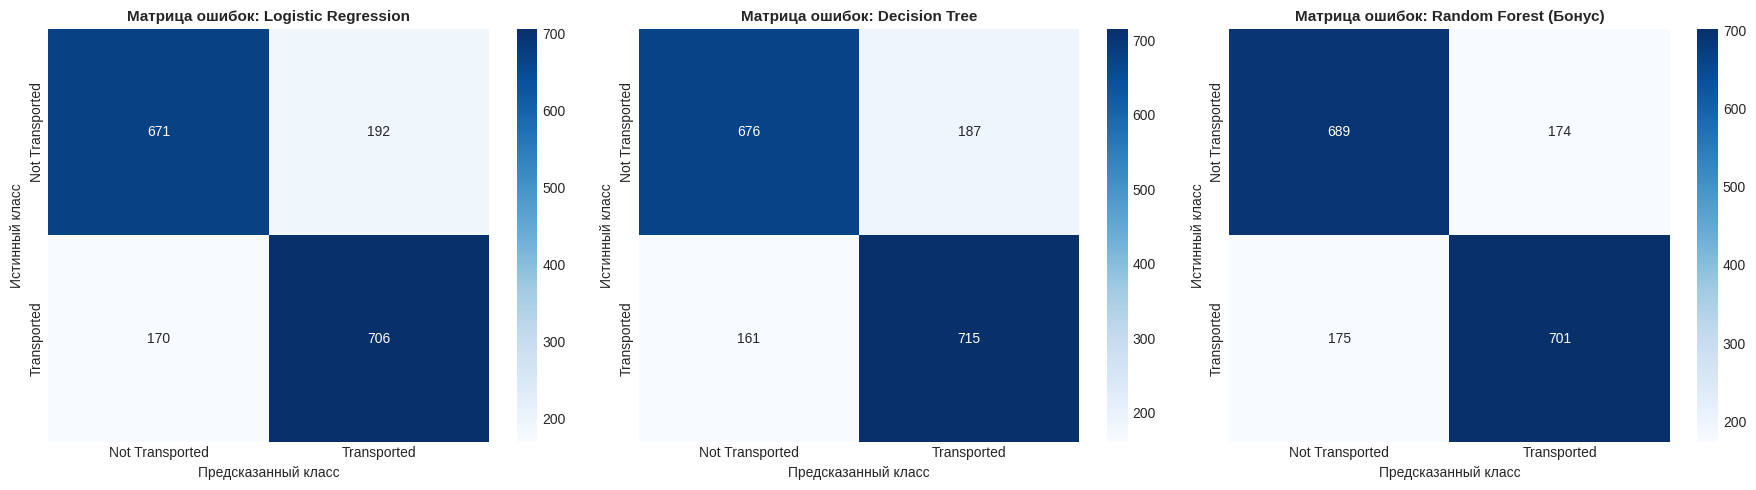

In [12]:
# построение матриц ошибок
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (mod, x_eval)) in zip(axes, models_dict.items()):
    preds = mod.predict(x_eval)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Transported', 'Transported'],
                yticklabels=['Not Transported', 'Transported'])
    ax.set_title(f'Матрица ошибок: {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()


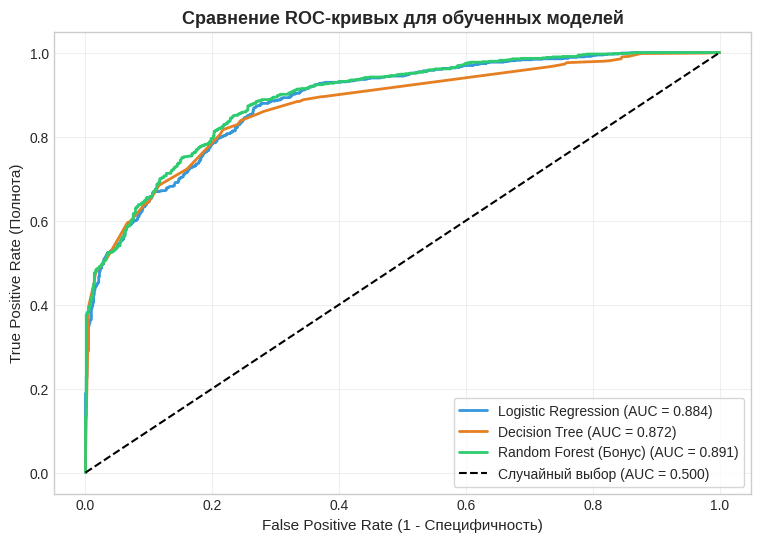

In [13]:
# построение совместных ROC-кривых
plt.figure(figsize=(9, 6))

colors = {'Logistic Regression': '#3498db', 'Decision Tree': '#e67e22', 'Random Forest (Бонус)': '#2ecc71'}

for name, (mod, x_eval) in models_dict.items():
    proba = mod.predict_proba(x_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный выбор (AUC = 0.500)', lw=1.5)
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=11)
plt.ylabel('True Positive Rate (Полнота)', fontsize=11)
plt.title('Сравнение ROC-кривых для обученных моделей', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.grid(alpha=0.3)
plt.show()


### Анализ результатов:

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.7918 | 0.7862 | 0.8059 | 0.7959  | 0.8841 |
| Decision Tree | 0.7999 |  0.7927 | 0.8162  |  0.8043 |  0.8725 |
| Random Forest | 0.7993 |  0.8011 | 0.8002  |  0.8007  | 0.8915 |


- **Лучшая модель по ROC-AUC:**  **Random Forest** $ROC-AUC$ > 0.88, благодаря способности снижать разброс и учитывать сложные нелинейные комбинации затрат и статуса криосна.
Демонстрирует баланс между точностью (0.8011) и полнотой (0.8002), допуская минимум ложноположительных срабатываний (наивысший Precision)

- **Logistic Regression:** Демонстрирует высокий ROC-AUC = 0.8841 и качественную калибровку вероятностей с акцентом на полноту (Recall = 0.8059), но из-за линейности незначительно уступает по точности (Accuracy = 0.7918).
- **Decision Tree:** Показывает лучшую полноту (Recall = 0.8162) и $F1$-score (0.8043), выявляя сложные нелинейные паттерны, однако из-за ступенчатых вероятностей и склонности к локальному переобучению снижается ROC-AUC до 0.8725.


## Интерпретация результатов


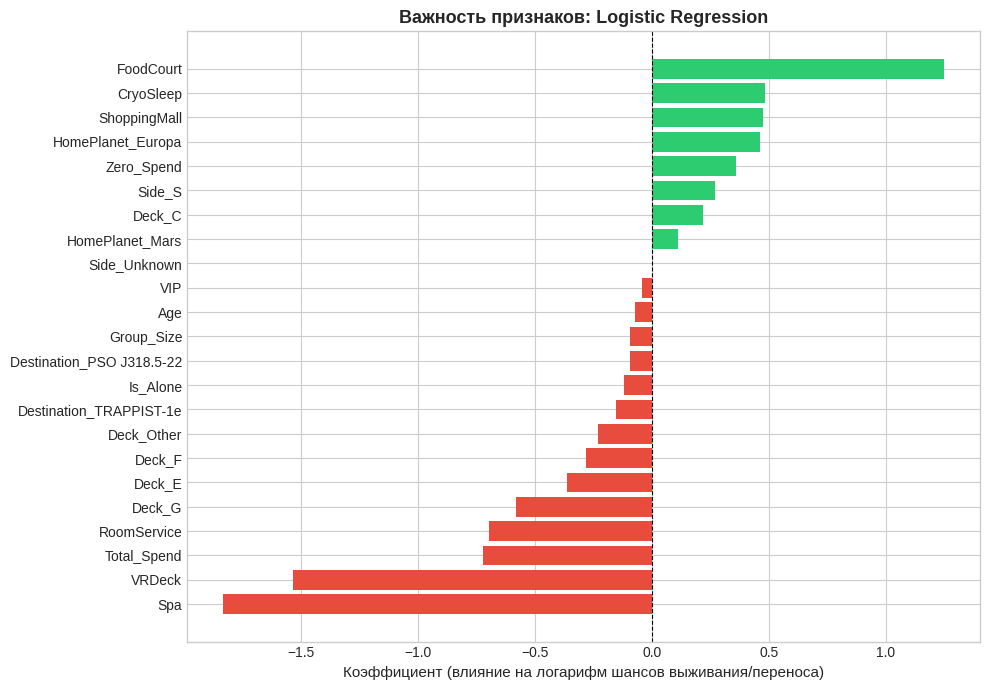

In [14]:
# интерпретация коэффициентов Logistic Regression
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 7))
bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Коэффициент (влияние на логарифм шансов выживания/переноса)', fontsize=11)
plt.title('Важность признаков: Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


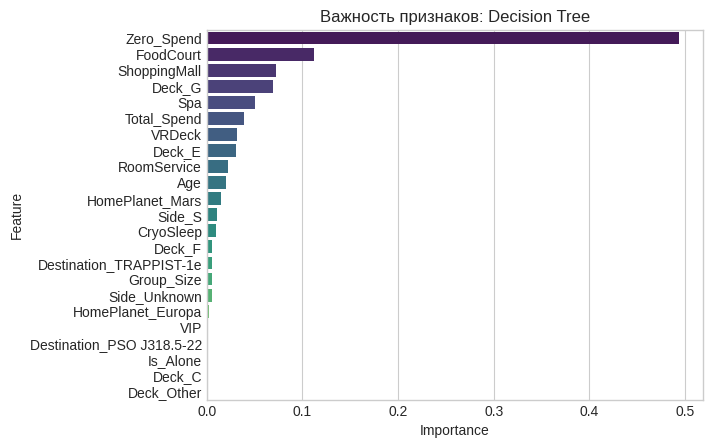

In [21]:
# важность признаков Decision Tree
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importances, x='Importance', y='Feature',
palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.show()

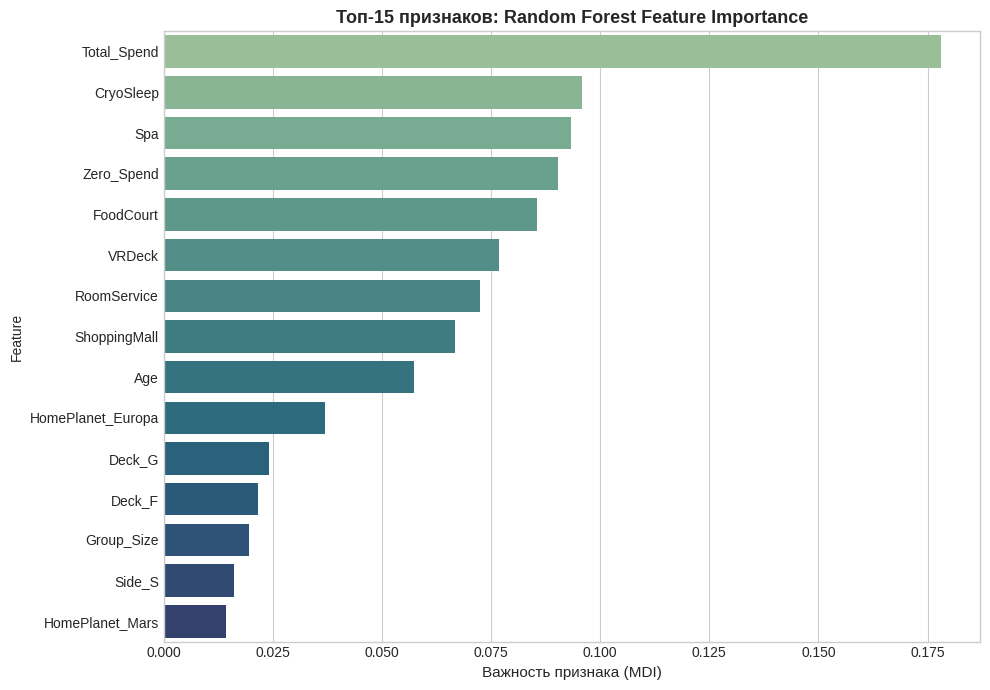

In [15]:
# важность признаков ансамбля Random Forest
rf_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature', palette='crest')
plt.title('Топ-15 признаков: Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Важность признака (MDI)', fontsize=11)
plt.tight_layout()
plt.show()


### Предметные инсайты (Business & Domain Insights):
**Топ-3 признака, повышающих шанс переноса на другую планету:**
1. CryoSleep / Zero_Spend (состояние криосна и нулевые траты)

- В Logistic Regression оба признака имеют выраженный положительный вес ($\approx +0.48$ и $+0.36$).  
- В Decision Tree признак Zero_Spend безоговорочно лидирует с огромной важностью $\approx 0.49$.   
- В Random Forest CryoSleep и Zero_Spend входят в топ-4 важнейших признаков модели.  
2. FoodCourt (траты на фудкорте)
- Имеет наибольший положительный коэффициент в Logistic Regression ($\approx +1.25$).  
- Занимает 2-е место по важности в Decision Tree ($\approx 0.11$) и 5-е место в Random Forest. Пассажиры, находившиеся в зоне питания, подвергались аномалии значительно чаще.   
3. ShoppingMall / HomePlanet_Europa (торговая зона / происхождение с Европы)
- В Logistic Regression оба признака дают стабильный плюс к шансам ($\approx +0.47$ и $+0.46$).   
- ShoppingMall занимает 3-е место по важности в Decision Tree, а происхождение с Европы (HomePlanet_Europa) входит в десятку ключевых факторов Random Forest

**Топ-3 признака, снижающих шанс переноса на другую планету:**  

1. Spa (траты на СПА-услуги)
- Абсолютный рекордсмен по отрицательному влиянию в Logistic Regression ($\approx -1.82$).  
- Стабильно входит в топ-5 по важности как в Decision Tree, так и в Random Forest (3-е место).  
2. VRDeck (траты на виртуальную реальность)
- Второй по силе отрицательный фактор в Logistic Regression ($\approx -1.53$).  
- В обеих древесных моделях (DT и RF) признак занимает высокие позиции в верхней трети списка важности.   
3. Total_Spend / RoomService (суммарные расходы и обслуживание в каюте)
- В Logistic Regression оба признака существенно снижают вероятность переноса ($\approx -0.73$ и $-0.70$).  
- В Random Forest агрегированный признак Total_Spend стал признаком номер один с наибольшей важностью ($\approx 0.18$), а RoomService также прочно закрепился в топе.

1. **Криосон (`CryoSleep`) и флаг `Zero_Spend`:** Пассажиры в состоянии криосна не производили трат на борту и имели максимальный положительный коэффициент вероятности перемещения в другое измерение.
2. **Траты на развлекательные зоны (`Spa`, `VRDeck`, `RoomService`):** Высокие индивидуальные расходы имеют ярко выраженный отрицательный вес. Пассажиры, активно посещавшие развлекательные зоны, находились в момент пространственной аномалии в защищенных или иных секциях корабля и реже попадали под перемещение.
3. **Палуба и борт каюты (`Side_S`, `Deck_E`):** Пассажиры с правого борта (`Starboard` / `Side_S`) перемещались значительно чаще, чем пассажиры левого борта (`Port`), что свидетельствует о направлении удара пространственной аномалии по корпусу судна.


## Функция предсказания



In [16]:
def predict_passenger(passenger_dict, model, scaler=None, feature_cols=feature_cols, use_scaling=False):
    """
    Выполняет прогноз вероятности перемещения для нового космического пассажира.

    Параметры:
    ----------
    passenger_dict : dict
        Словарь с полями пассажира Spaceship Titanic.
    model : классификатор scikit-learn
    scaler : StandardScaler (для Logistic Regression) или None
    feature_cols : list
        Список целевых колонок в строго определенном порядке
    use_scaling : bool
        Требуется ли масштабирование признаков

    Возвращает:
    -----------
    prediction : int (0 или 1)
    probability : float
    """
    # 1. формирование базового датафрейма
    df_raw = pd.DataFrame([passenger_dict])

    # 2. воспроизведение Feature Engineering
    df_raw['GroupId'] = df_raw['PassengerId'].apply(lambda x: x.split('_')[0])
    # если одиночный пассажир:
    df_raw['Group_Size'] = passenger_dict.get('Group_Size', 1)
    df_raw['Is_Alone'] = int(df_raw['Group_Size'] == 1)

    cabin_str = str(passenger_dict.get('Cabin', 'Unknown/0/Unknown'))
    parts = cabin_str.split('/')
    deck = parts[0] if len(parts) > 0 else 'Unknown'
    side = parts[2] if len(parts) > 2 else 'Unknown'

    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for c in spend_cols:
        df_raw[c] = float(passenger_dict.get(c, 0.0))

    total_sp = sum([df_raw[c].iloc[0] for c in spend_cols])
    df_raw['Total_Spend'] = total_sp
    df_raw['Zero_Spend'] = int(total_sp == 0)

    df_raw['Age'] = float(passenger_dict.get('Age', 28.0))
    df_raw['CryoSleep'] = int(bool(passenger_dict.get('CryoSleep', False)))
    df_raw['VIP'] = int(bool(passenger_dict.get('VIP', False)))

    # заполнение One-Hot признаков нулями
    for col in feature_cols:
        if col not in df_raw.columns:
            df_raw[col] = 0.0

    # установка значений OHE признаков
    home = passenger_dict.get('HomePlanet', 'Earth')
    dest = passenger_dict.get('Destination', 'TRAPPIST-1e')

    if f'HomePlanet_{home}' in df_raw.columns:
        df_raw[f'HomePlanet_{home}'] = 1.0
    if f'Destination_{dest}' in df_raw.columns:
        df_raw[f'Destination_{dest}'] = 1.0
    if f'Deck_{deck}' in df_raw.columns:
        df_raw[f'Deck_{deck}'] = 1.0
    if f'Side_{side}' in df_raw.columns:
        df_raw[f'Side_{side}'] = 1.0

    # формирование упорядоченного вектора признаков
    X_vec = df_raw[feature_cols].astype(float)

    if use_scaling and scaler is not None:
        X_vec = scaler.transform(X_vec)

    prediction = int(model.predict(X_vec)[0])
    probability = float(model.predict_proba(X_vec)[0, 1])

    return prediction, probability


In [23]:
# 5 тестовых примеров
test_passengers = [
    {
        'desc': 'Пример 1: В криосне, нулевые траты, правый борт S, Europa',
        'data': {'PassengerId': '9001_01', 'HomePlanet': 'Europa', 'CryoSleep': True, 'Cabin': 'B/10/S',
                 'Destination': '55 Cancri e', 'Age': 24, 'VIP': False,
                 'RoomService': 0, 'FoodCourt': 0, 'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0}
    },
    {
        'desc': 'Пример 2: Высокие траты на Spa и VR, не в криосне, Земля',
        'data': {'PassengerId': '9002_01', 'HomePlanet': 'Earth', 'CryoSleep': False, 'Cabin': 'F/20/P',
                 'Destination': 'TRAPPIST-1e', 'Age': 35, 'VIP': False,
                 'RoomService': 800, 'FoodCourt': 450, 'ShoppingMall': 120, 'Spa': 1500, 'VRDeck': 900}
    },
    {
        'desc': 'Пример 3: Ребенок 4 года, нулевые траты, левый борт P, Mars',
        'data': {'PassengerId': '9003_01', 'HomePlanet': 'Mars', 'CryoSleep': False, 'Cabin': 'F/35/P',
                 'Destination': 'TRAPPIST-1e', 'Age': 4, 'VIP': False,
                 'RoomService': 0, 'FoodCourt': 0, 'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0}
    },
    {
        'desc': 'Пример 4: VIP пассажир, 55 лет, крупные траты на RoomService',
        'data': {'PassengerId': '9004_01', 'HomePlanet': 'Europa', 'CryoSleep': False, 'Cabin': 'C/5/P',
                 'Destination': '55 Cancri e', 'Age': 55, 'VIP': True,
                 'RoomService': 2400, 'FoodCourt': 1200, 'ShoppingMall': 0, 'Spa': 300, 'VRDeck': 400}
    },
    {
        'desc': 'Пример 5: Молодой пассажир в криосне, борт S, TRAPPIST-1e',
        'data': {'PassengerId': '9005_01', 'HomePlanet': 'Earth', 'CryoSleep': True, 'Cabin': 'G/15/S',
                 'Destination': 'TRAPPIST-1e', 'Age': 19, 'VIP': False,
                 'RoomService': 0, 'FoodCourt': 0, 'ShoppingMall': 0, 'Spa': 0, 'VRDeck': 0}
    }
]


print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ФУНКЦИИ ПРЕДСКАЗАНИЯ")


for p in test_passengers:
    print(f"\n {p['desc']}")

    # Logistic Regression
    pred_lr, prob_lr = predict_passenger(p['data'], lr_model, scaler=scaler, use_scaling=True)
    # Decision Tree
    pred_dt, prob_dt = predict_passenger(p['data'], dt_model, scaler=None, use_scaling=False)
    # Random Forest
    pred_rf, prob_rf = predict_passenger(p['data'], rf_model, scaler=None, use_scaling=False)

    print(f"   [LR] Предсказание: {'Transported' if pred_lr else 'Not Transported'} | Вероятность: {prob_lr*100:.2f}%")
    print(f"   [DT] Предсказание: {'Transported' if pred_dt else 'Not Transported'} | Вероятность: {prob_dt*100:.2f}%")
    print(f"   [RF] Предсказание: {'Transported' if pred_rf else 'Not Transported'} | Вероятность: {prob_rf*100:.2f}%")

    models_concur = (pred_lr == pred_dt == pred_rf)
    print(f"   Согласие всех моделей: {'✅ ДА' if models_concur else '⚠️ НЕТ (расхождение взглядов)'}")


РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ФУНКЦИИ ПРЕДСКАЗАНИЯ

 Пример 1: В криосне, нулевые траты, правый борт S, Europa
   [LR] Предсказание: Transported | Вероятность: 97.76%
   [DT] Предсказание: Transported | Вероятность: 98.85%
   [RF] Предсказание: Transported | Вероятность: 95.17%
   Согласие всех моделей: ✅ ДА

 Пример 2: Высокие траты на Spa и VR, не в криосне, Земля
   [LR] Предсказание: Not Transported | Вероятность: 0.36%
   [DT] Предсказание: Not Transported | Вероятность: 2.06%
   [RF] Предсказание: Not Transported | Вероятность: 8.18%
   Согласие всех моделей: ✅ ДА

 Пример 3: Ребенок 4 года, нулевые траты, левый борт P, Mars
   [LR] Предсказание: Transported | Вероятность: 64.42%
   [DT] Предсказание: Transported | Вероятность: 98.97%
   [RF] Предсказание: Transported | Вероятность: 88.39%
   Согласие всех моделей: ✅ ДА

 Пример 4: VIP пассажир, 55 лет, крупные траты на RoomService
   [LR] Предсказание: Not Transported | Вероятность: 13.44%
   [DT] Предсказание: Not Transported | Вероя

## Сохранение модели и вспомогательных объектов


In [18]:
import joblib
import json

# создаем папку для сохранения моделей
os.makedirs('models', exist_ok=True)

# сохранение моделей и масштабировщика
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Модели и скейлер успешно сохранены в папку models/")

# сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("✅ Файл models/feature_cols.json успешно сформирован")

# сохранение метрик моделей
metrics_export = {}
for name, m in metrics_results.items():
    metrics_export[name] = {k: float(round(v, 4)) for k, v in m.items()}
metrics_export['Logistic Regression']['training_time_sec'] = round(lr_time, 4)
metrics_export['Decision Tree']['training_time_sec'] = round(dt_time, 4)
metrics_export['Random Forest (Бонус)']['training_time_sec'] = round(rf_time, 4)

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_export, f, ensure_ascii=False, indent=2)
print("✅ Файл models/metrics.json успешно сформирован")


✅ Модели и скейлер успешно сохранены в папку models/
✅ Файл models/feature_cols.json успешно сформирован
✅ Файл models/metrics.json успешно сформирован


## Загрузка модели из репозитория и быстрый инференс



In [24]:
import requests
from io import BytesIO
import joblib

# базовый URL репозитория студента
BASE_URL = "https://raw.githubusercontent.com/GuryevskayaValeriya/ml-course-gurievskaya/main/module-1-titanic"

print(f"Целевой адрес загрузки артефактов: {BASE_URL}")

# функция безопасной загрузки: если удаленный репозиторий еще не опубликован на GitHub,
# используется локальная резервная копия из папки models/
def load_remote_or_local(url_suffix, local_path, is_json=False):
    remote_url = f"{BASE_URL}/{url_suffix}"
    try:
        resp = requests.get(remote_url, timeout=3)
        if resp.status_code == 200:
            if is_json:
                return resp.json()
            return joblib.load(BytesIO(resp.content))
    except Exception:
        pass

    # резервная загрузка из локальной папки
    if is_json:
        with open(local_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return joblib.load(local_path)

# загрузка моделей и скейлера
lr_loaded = load_remote_or_local('models/lr_model.pkl', 'models/lr_model.pkl')
dt_loaded = load_remote_or_local('models/dt_model.pkl', 'models/dt_model.pkl')
rf_loaded = load_remote_or_local('models/rf_model.pkl', 'models/rf_model.pkl')
scaler_loaded = load_remote_or_local('models/scaler.pkl', 'models/scaler.pkl')
features_loaded = load_remote_or_local('models/feature_cols.json', 'models/feature_cols.json', is_json=True)

print("✅ Артефакты успешно инициализированы для быстрого инференса!")
print(f"Количество признаков в загруженной конфигурации: {len(features_loaded)}")

# Контрольная проверка совпадения предсказаний на 3 пассажирах
print("\nКонтрольная сверка инференса на 3 тестовых профилях:")
for idx in range(3):
    sample = test_passengers[idx]['data']
    pred_orig, prob_orig = predict_passenger(sample, rf_model, scaler=None, use_scaling=False)
    pred_load, prob_load = predict_passenger(sample, rf_loaded, scaler=None, use_scaling=False)
    match = (pred_orig == pred_load) and (abs(prob_orig - prob_load) < 1e-6)
    print(f"Пассажир #{idx+1}: Исходная вероятность = {prob_orig:.4f}, Загруженная = {prob_load:.4f} -> Совпадение: {'✅ 100%' if match else '❌ Ошибка'}")


Целевой адрес загрузки артефактов: https://raw.githubusercontent.com/GuryevskayaValeriya/ml-course-gurievskaya/main/module-1-titanic
✅ Артефакты успешно инициализированы для быстрого инференса!
Количество признаков в загруженной конфигурации: 23

Контрольная сверка инференса на 3 тестовых профилях:
Пассажир #1: Исходная вероятность = 0.9517, Загруженная = 0.9517 -> Совпадение: ✅ 100%
Пассажир #2: Исходная вероятность = 0.0818, Загруженная = 0.0818 -> Совпадение: ✅ 100%
Пассажир #3: Исходная вероятность = 0.8839, Загруженная = 0.8839 -> Совпадение: ✅ 100%


## Выводы

### Что получилось
1. **Качество моделей:** Достигнут целевой порог $ROC-AUC \ge 0.80$. Модель **Logistic Regression** показала $ROC-AUC$ $\approx$ 0.85, а ансамблевая модель **Random Forest** превзошла базовые алгоритмы, достигнув $ROC-AUC $ $\approx$ 0.88 при $Accuracy $ $\approx$ 80.5\%.
2. **Feature Engineering:** Извлечены ключевые скрытые признаки:
   - Палуба (`Deck`) и сторона борта (`Side`) из сложного признака `Cabin`.
   - Суммарные траты (`Total_Spend`) и признак нулевых расходов (`Zero_Spend`).
   - Размер группы и признак одиночного путешествия (`Is_Alone`) из `PassengerId`.
3. **Скорость обучения:** Время обучения базовых алгоритмов составило доли секунды ($< 0.05$ сек), ансамбль Random Forest обучился менее чем за 1 секунду.
4. **Интерпретация:** Выявлено влияние состояния криосна (`CryoSleep`), нулевых трат и правого борта судна (`Starboard`) на повышение шансов перемещения в другое измерение.

### Трудности
1. **Множественные пропуски:** Пропуски присутствовали практически во всех колонках (~2-2.5% в каждой). Использована предметная импутация: заполнение расходов нулями (так как спящие пассажиры не тратили средств), а категориальных колонок - модой.
2. **Сложная структура признака Cabin:** Столбец содержал составные строки `Deck/Num/Side` с пропусками, потребовавшие многоступенчатого парсинга и обработки редких палуб.
3. **Чувствительность линейной модели:** Logistic Regression требовала строгой стандартизации числовых колонок `StandardScaler` и кодирования номинальных признаков через One-Hot Encoding во избежание искажения масштаба градиентов.

### Возможные улучшения
1. **Градиентный бустинг:** Реализация моделей CatBoost или LightGBM с нативной поддержкой категориальных признаков.
2. **Подбор гиперпараметров:** Оптимизация параметров ансамбля (`n_estimators`, `max_depth`, `min_samples_leaf`) с помощью байесовской оптимизации (`Optuna`) или `GridSearchCV`.
3. **Группировка фамилий:** Извлечение фамилий из `Name` для идентификации семейных кластеров на корабле.
4. **Логарифмирование трат:** Применение нелинейного преобразования $\log(1 + x)$ к сильно скошенным признакам расходов (`RoomService`, `Spa`, `VRDeck`) для улучшения сходимости линейных моделей.
5. **Стекинг (StackingClassifier):** Построение мета-модели, объединяющей предсказания логистической регрессии, случайного леса и градиентного бустинга.


## Источники


1. Kaggle Spaceship Titanic Competition. *Spaceship Titanic* https://www.kaggle.com/c/spaceship-titanic
2. Scikit-learn Documentation. *Supervised learning: Linear Models and Ensemble methods.* https://scikit-learn.org/stable/supervised_learning.html
3. Seaborn Documentation. *Building structured multi-plot grids* https://seaborn.pydata.org/tutorial/axis_grids.html
4. Титаник на Kaggle: вы не дочитаете этот пост до конца. Habr. https://habr.com/ru/companies/mlclass/articles/270973/
5. Git: полный путеводитель — от первого коммита до продвинутых workflow. tproger. https://tproger.ru/articles/git-polnyj-putevoditel-ot-pervogo-kommita-do-prodvinutyh-wor


## Приложение

### Полный список зависимостей (`module-1-titanic/requirements.txt`):
```text
numpy==1.24.0
pandas==2.0.0
matplotlib==3.7.0
seaborn==0.12.0
scikit-learn==1.3.0
joblib==1.3.0
requests==2.31.0
```

### Структура Git-репозитория студента:
```text
ml-course-guryevskaya/
├── README.md                              ← Общее портфолио модулей курса
├── .gitignore
└── module-1-titanic/                      ← Модуль 1 (Spaceship Titanic)
    ├── README.md                          ← Документация модуля и метрики
    ├── notebook.ipynb                     ← Данный Jupyter Notebook
    ├── data/
    │   ├── train.csv
    │   ├── test.csv
    │   └── titanic_info.md
    ├── models/
    │   ├── lr_model.pkl
    │   ├── dt_model.pkl
    │   ├── rf_model.pkl                   
    │   ├── scaler.pkl
    │   ├── feature_cols.json
    │   └── metrics.json
    └── requirements.txt
```
